# PCA・UMAPによる可視化とクラスタリング

`MNICT_train.csv` を使い、PCA、UMAP、階層的クラスタリング、k-means を実行するNotebookです。

第2回〜第5回と同じように、CSVを読み込み、前処理をしてから機械学習・可視化を行います。今回のデータには正解ラベル列がないため、PCAやUMAPの点は主にクラスタリング結果で色付けします。

## ライブラリの読み込み

このセルでは、データ処理、グラフ作成、PCA、UMAP、クラスタリングに必要なライブラリを読み込む。乱数を固定するための `RANDOM_STATE` もここで設定する。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import BoundaryNorm, ListedColormap

# 乱数を固定して、サンプリングやクラスタリングの結果を再現できるようにする。
RANDOM_STATE = 42

# グラフの見た目をそろえる。
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

/Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python_seminar/第6回/lesson_6/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 設定値

このセルでは、PCAの主成分数、UMAPや階層クラスタリングに使うサンプル数、クラスタ数をまとめて設定する。

階層的クラスタリングは全サンプル同士の距離を扱うため、60,000件すべてに直接実行すると計算量が大きく、デンドログラムも読みにくくなる。そのため、階層的クラスタリングとUMAPはサンプルを抽出して実行する。

In [2]:
CSV_PATH = Path('MNICT_train.csv')

# PCA は全データで実行する。PC1〜PC10の可視化に加え、UMAP用に多めに主成分を残す。
PCA_N_COMPONENTS = 100

# PC1〜PC10の10×10プロットやPCA散布図で表示するサンプル数。
# 全60,000点を散布図行列に使うと描画が重くなるため、表示用にサンプリングする。
PLOT_SAMPLE_SIZE = 3000

# UMAP はPCA後の主成分スコアを入力にして計算を軽くする。
UMAP_SAMPLE_SIZE = 3000
UMAP_PCA_COMPONENTS = 50

# 階層的クラスタリングは、標準化済みデータからサンプルを抽出してウォード法で実行する。
HIERARCHICAL_SAMPLE_SIZE = 1200
DENDROGRAM_LAST_P = 50

# MNIST系の画像データを想定し、0〜9の10種類に対応する10クラスタを基本設定にする。
N_CLUSTERS = 10

## 補助関数

このセルでは、サンプル抽出、クラスタ色の設定、散布図作成を行う関数を定義する。

In [3]:
def make_sample_positions(n_samples, sample_size, random_state=RANDOM_STATE):
    """指定した件数だけ、行番号をランダムに抽出する。"""
    if sample_size is None or sample_size >= n_samples:
        return np.arange(n_samples)

    rng = np.random.default_rng(random_state)
    return np.sort(rng.choice(n_samples, size=sample_size, replace=False))


def make_cluster_color_settings(n_clusters):
    """クラスタ番号を1, 2, ...として表示するためのカラーマップを作る。"""
    base_colors = plt.get_cmap('tab10').colors
    color_list = [base_colors[i % len(base_colors)] for i in range(n_clusters)]
    cmap = ListedColormap(color_list)
    norm = BoundaryNorm(np.arange(0.5, n_clusters + 1.5), n_clusters)
    return cmap, norm


def plot_pca_scatter(ax, score_df, title, color_values=None, cmap=None, norm=None, colorbar_label=None):
    """PC1とPC2の散布図を描く。"""
    if color_values is None:
        scatter = ax.scatter(score_df['PC1'], score_df['PC2'], s=6, alpha=0.35, color='tab:blue')
    else:
        scatter = ax.scatter(
            score_df['PC1'],
            score_df['PC2'],
            c=color_values,
            s=8,
            alpha=0.65,
            cmap=cmap,
            norm=norm,
        )

    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.axhline(0, color='gray', linewidth=0.6)
    ax.axvline(0, color='gray', linewidth=0.6)

    if color_values is not None and colorbar_label is not None:
        colorbar = plt.colorbar(scatter, ax=ax, ticks=np.arange(1, N_CLUSTERS + 1))
        colorbar.set_label(colorbar_label)

    return scatter

## CSVファイルの読み込み

このセルでは、`MNICT_train.csv` を pandas の DataFrame として読み込む。1列目の `Unnamed: 0` はサンプル番号なので、行名として使う。

In [4]:
# CSVファイルを読み込む。
# 1列目が Unnamed で始まる場合は、サンプル番号として index にする。
raw_df = pd.read_csv(CSV_PATH)

if raw_df.columns[0].startswith('Unnamed'):
    df = raw_df.set_index(raw_df.columns[0])
    df.index.name = 'sample_id'
else:
    df = raw_df.copy()

print(f'データ数: {df.shape[0]}')
print(f'列数: {df.shape[1]}')

# 列数が多いため、先頭5行・先頭12列だけ表示して確認する。
display(df.iloc[:5, :12])

データ数: 60000
列数: 784


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,pixel_11
sample_id,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0


## データの基本情報の確認

このセルでは、欠損値、数値列、正解ラベル列の有無を確認する。今回のCSVには `label` や `target` のような正解ラベル列は含まれていない。

In [5]:
# 欠損値を確認する。
print(f'欠損値の合計: {int(df.isna().sum().sum())}')

# 正解ラベルらしい列があるか確認する。
# 今回のデータでは見つからないため、教師なし学習として扱う。
label_candidates = ['label', 'Label', 'target', 'Target', 'class', 'Class', 'species', 'Species', 'y', 'Y']
label_column = next((column for column in label_candidates if column in df.columns), None)

if label_column is None:
    y = None
    x = df.select_dtypes(include='number').copy()
    print('正解ラベル列は見つかりませんでした。')
else:
    y = df[label_column].copy()
    x = df.drop(columns=[label_column]).select_dtypes(include='number').copy()
    print(f'正解ラベル列: {label_column}')

print(f'説明変数の数: {x.shape[1]}')
print(f'説明変数のデータ型:')
print(x.dtypes.value_counts())

# 分散が0の列は、全サンプルで同じ値の特徴量。
# StandardScalerでは0に変換されるため、そのままでもPCAやクラスタリングに悪影響は小さい。
constant_columns = x.columns[x.nunique() <= 1]
print(f'分散が0の列数: {len(constant_columns)}')

欠損値の合計: 0
正解ラベル列は見つかりませんでした。
説明変数の数: 784
説明変数のデータ型:
int64    784
Name: count, dtype: int64
分散が0の列数: 67


## 前処理

このセルでは、ピクセル値を 0〜1 にそろえたあと、`StandardScaler` でオートスケーリングする。

PCA、ウォード法、k-means は距離や分散の影響を受けるため、説明変数のスケールをそろえてから実行する。

In [6]:
# 画像のピクセル値は 0〜255 の整数なので、まず 255 で割って 0〜1 にする。
x_01 = x.astype('float32') / 255.0

# オートスケーリングを行う。
# fit_transform() は平均と標準偏差を学習し、その値を使って変換する処理。
scaler = StandardScaler()
auto_x = scaler.fit_transform(x_01).astype('float32')

auto_x_df = pd.DataFrame(auto_x, index=x.index, columns=x.columns)
print(f'前処理後の行数・列数: {auto_x_df.shape}')
display(auto_x_df.iloc[:5, :12])

前処理後の行数・列数: (60000, 784)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,pixel_11
sample_id,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## PCAの実行

このセルでは、全データに対してPCAを実行する。

`score` は各サンプルの主成分スコア、`loadings` は各特徴量が主成分にどのように効いているかを表すローディング、`contribution_ratios` は寄与率と累積寄与率をまとめた表である。

In [7]:
# PCAで残す主成分数は、サンプル数・説明変数数を超えないようにする。
n_components = min(PCA_N_COMPONENTS, auto_x_df.shape[0], auto_x_df.shape[1])

# randomized SVDを使うと、大きめのデータでも高速に上位主成分を計算できる。
pca = PCA(n_components=n_components, svd_solver='randomized', random_state=RANDOM_STATE)
pca_scores = pca.fit_transform(auto_x_df)

pc_columns = [f'PC{index}' for index in range(1, n_components + 1)]
score = pd.DataFrame(pca_scores, index=auto_x_df.index, columns=pc_columns)
loadings = pd.DataFrame(pca.components_.T, index=auto_x_df.columns, columns=pc_columns)

contribution_ratios = pd.DataFrame(
    {
        'principal_component': pc_columns,
        'contribution_ratio': pca.explained_variance_ratio_,
        'cumulative_contribution_ratio': np.cumsum(pca.explained_variance_ratio_),
    }
)

print(f'PCAで計算した主成分数: {n_components}')
display(contribution_ratios.head(10))
display(score.iloc[:5, :10])

PCAで計算した主成分数: 100


,principal_component,contribution_ratio,cumulative_contribution_ratio
0,PC1,0.056467,0.056467
1,PC2,0.040783,0.097250
2,PC3,0.037394,0.134644
3,PC4,0.028851,0.163495
4,PC5,0.025211,0.188706
5,PC6,0.021943,0.210649
6,PC7,0.019233,0.229882
7,PC8,0.017458,0.247340
8,PC9,0.015351,0.262691
9,PC10,0.014017,0.276708


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
sample_id,,,,,,,,,,
0,-0.922137,-4.814713,0.067528,8.051107,0.985350,0.951525,-0.336476,1.393354,-1.052418,2.325017
1,8.709007,-7.754373,-3.447967,1.668188,-0.834736,-5.144552,0.272306,3.135295,-0.198501,-1.196215
2,2.328405,9.431358,-6.184158,-1.725197,-4.092206,2.291689,-18.691303,3.992187,2.169553,-0.152257
3,-6.582162,-3.746233,3.690972,0.461195,-5.627389,3.461312,-1.561581,-4.600031,-0.624484,-2.616992
4,-5.183238,3.133286,-6.277982,-1.459777,1.608845,-0.612242,0.579502,-3.205890,0.012944,-0.698482


## 寄与率 vs 累積寄与率のプロット

このセルでは、各主成分の寄与率を棒グラフ、累積寄与率を折れ線グラフで表示する。

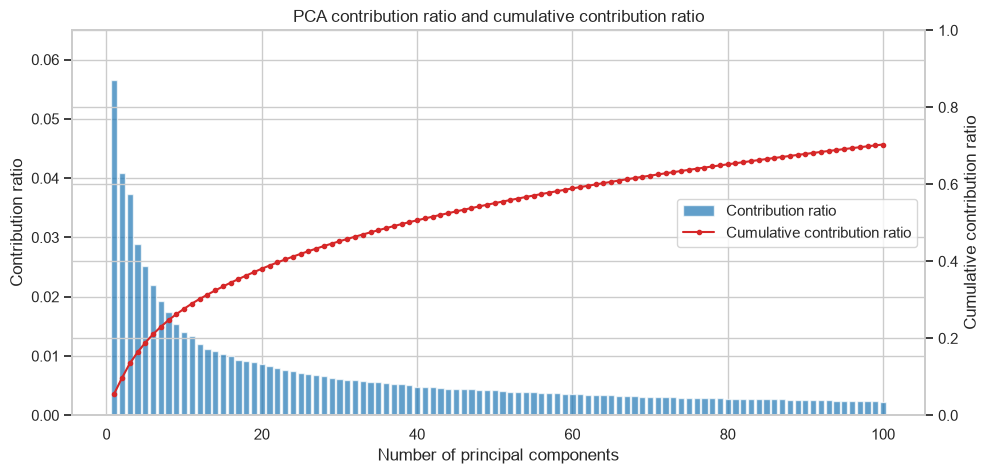

In [8]:
x_axis = np.arange(1, contribution_ratios.shape[0] + 1)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(
    x_axis,
    contribution_ratios['contribution_ratio'],
    color='tab:blue',
    alpha=0.70,
    label='Contribution ratio',
)
ax1.set_xlabel('Number of principal components')
ax1.set_ylabel('Contribution ratio')
ax1.set_ylim(0, contribution_ratios['contribution_ratio'].max() * 1.15)

ax2 = ax1.twinx()
ax2.plot(
    x_axis,
    contribution_ratios['cumulative_contribution_ratio'],
    color='tab:red',
    marker='o',
    markersize=3,
    linewidth=1.5,
    label='Cumulative contribution ratio',
)
ax2.set_ylabel('Cumulative contribution ratio')
ax2.set_ylim(0, 1.0)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
ax1.set_title('PCA contribution ratio and cumulative contribution ratio')
plt.show()

## PCAによる2次元可視化

このセルでは、PC1とPC2の散布図を作成する。正解ラベルがないため、ここでは点を同じ色で表示する。

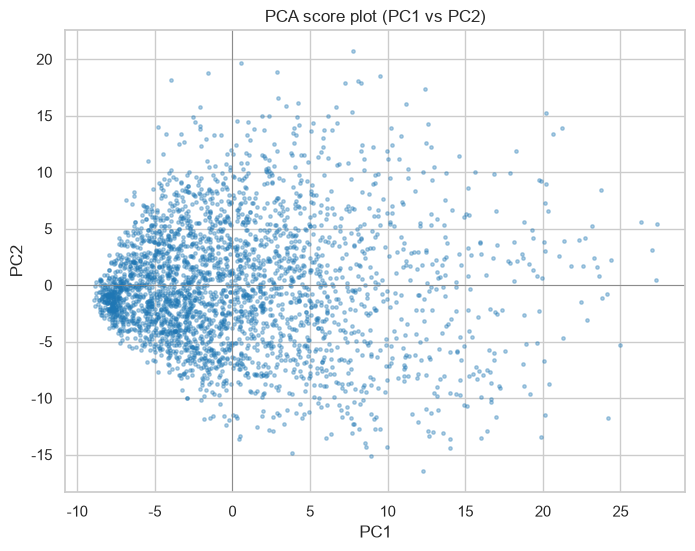

In [9]:
plot_positions = make_sample_positions(score.shape[0], PLOT_SAMPLE_SIZE)
score_plot = score.iloc[plot_positions].copy()

fig, ax = plt.subplots(figsize=(8, 6))
plot_pca_scatter(ax, score_plot, title='PCA score plot (PC1 vs PC2)')
plt.show()

## PC1〜PC10の10×10プロット

このセルでは、PC1〜PC10の散布図行列を作成する。対角成分には各PCのヒストグラム、それ以外には2つのPCの散布図を表示する。

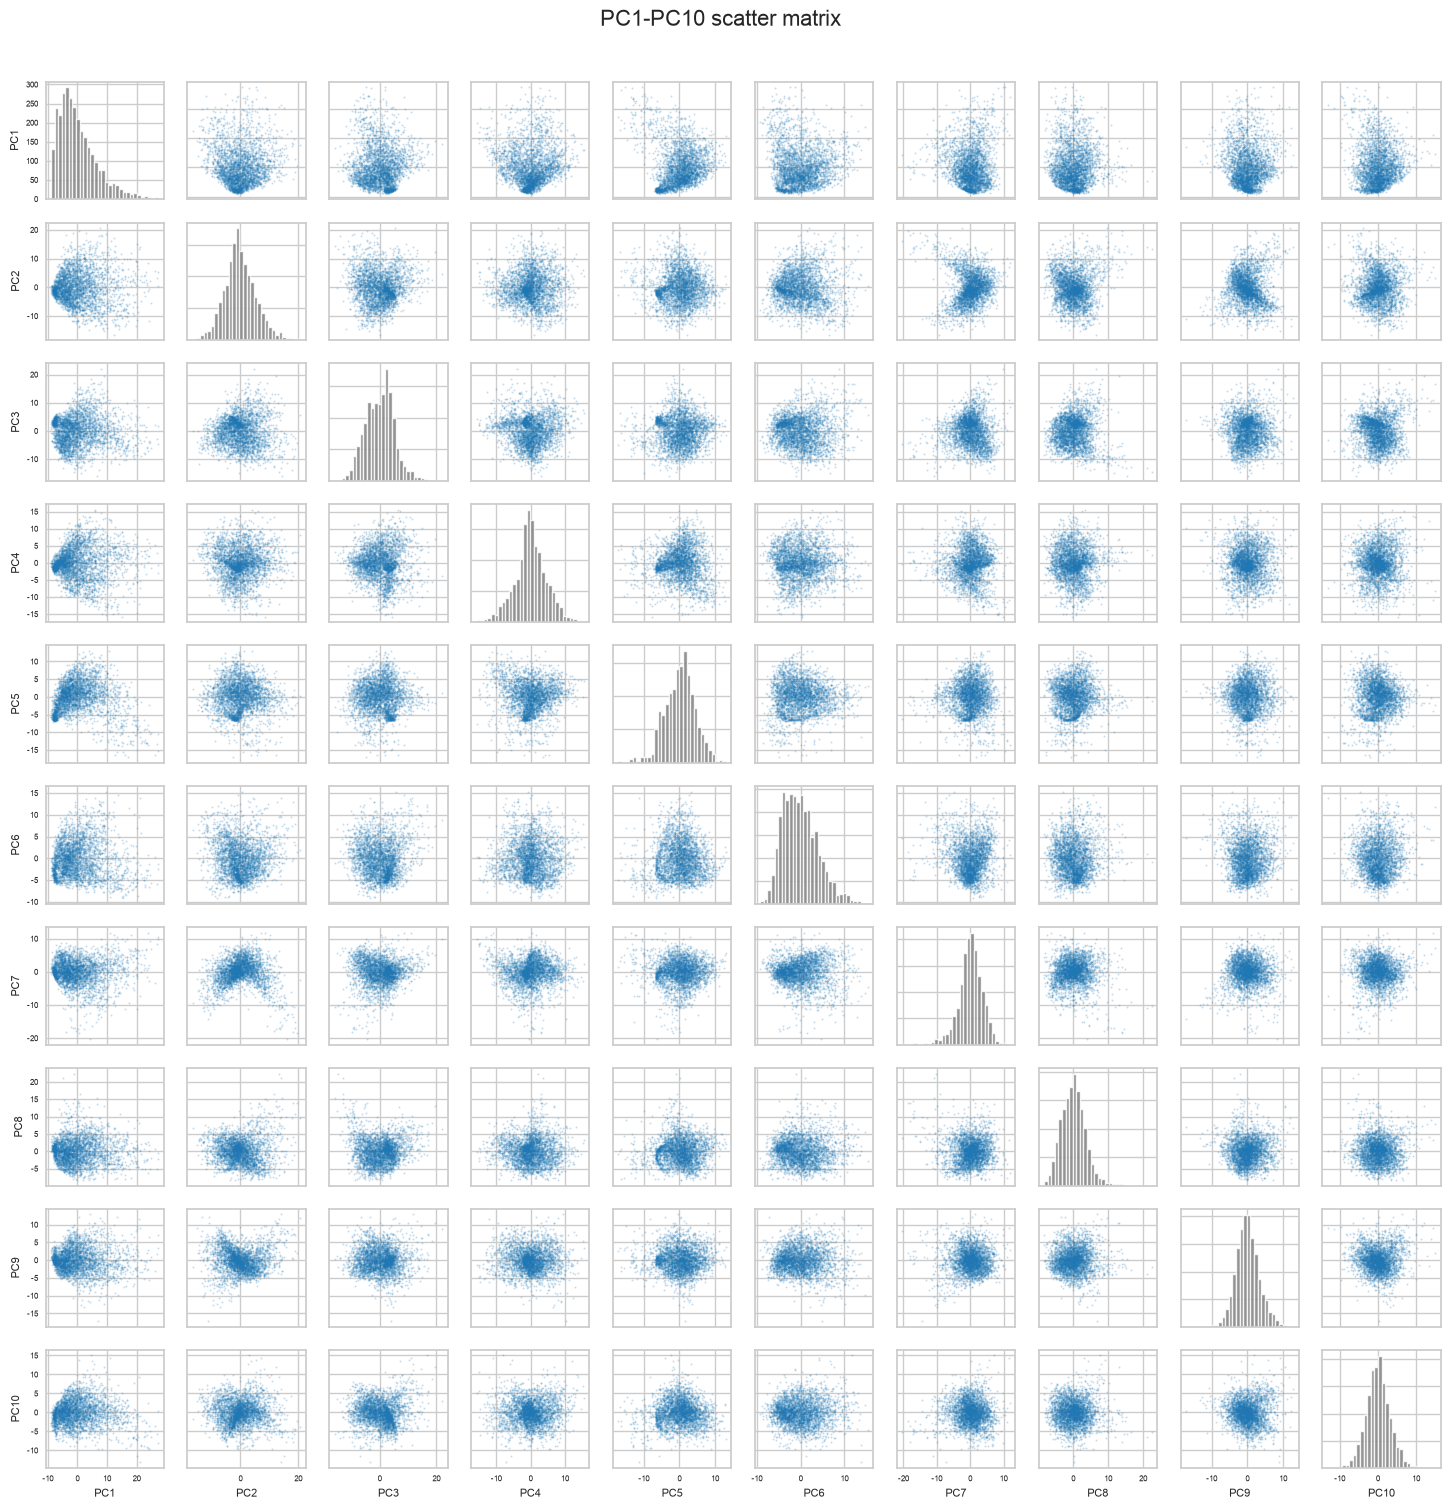

In [10]:
pair_pc_columns = pc_columns[:10]
pair_plot_df = score.iloc[plot_positions][pair_pc_columns]

fig, axes = plt.subplots(10, 10, figsize=(18, 18))

for row_index, row_pc in enumerate(pair_pc_columns):
    for column_index, column_pc in enumerate(pair_pc_columns):
        ax = axes[row_index, column_index]

        if row_index == column_index:
            ax.hist(pair_plot_df[column_pc], bins=30, color='gray', alpha=0.85)
        else:
            ax.scatter(
                pair_plot_df[column_pc],
                pair_plot_df[row_pc],
                s=2,
                alpha=0.25,
                color='tab:blue',
                linewidths=0,
            )

        if row_index == 9:
            ax.set_xlabel(column_pc, fontsize=8)
        else:
            ax.set_xticklabels([])

        if column_index == 0:
            ax.set_ylabel(row_pc, fontsize=8)
        else:
            ax.set_yticklabels([])

        ax.tick_params(axis='both', labelsize=6, length=2)

fig.suptitle('PC1-PC10 scatter matrix', y=0.92, fontsize=16)
plt.show()

## PCAローディングの可視化

スライドのメモにあるローディングも確認する。今回の特徴量は `pixel_0`〜`pixel_783` の784個なので、各主成分のローディングを 28×28 の画像として表示できる。

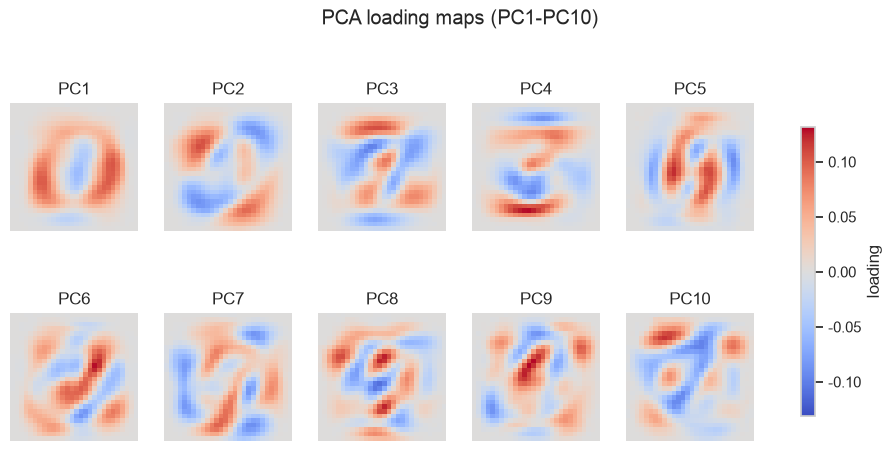

In [11]:
# pixel_0〜pixel_783 の784特徴量であれば、各PCのローディングを28×28画像として表示する。
if auto_x_df.shape[1] == 784:
    loading_images = pca.components_[:10].reshape(10, 28, 28)
    vmax = np.abs(loading_images).max()

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for index, ax in enumerate(axes.ravel()):
        image = ax.imshow(loading_images[index], cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.set_title(f'PC{index + 1}')
        ax.axis('off')

    fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75, label='loading')
    fig.suptitle('PCA loading maps (PC1-PC10)', y=1.02)
    plt.show()
else:
    display(loadings.iloc[:20, :10])

## UMAPによる可視化

このセルでは、PCAスコアを入力にしてUMAPで2次元に圧縮する。

UMAPを生の784次元データに直接かけることもできるが、ここでは計算を軽くし、ノイズの影響を少し抑えるため、PCAの上位主成分を入力にする。

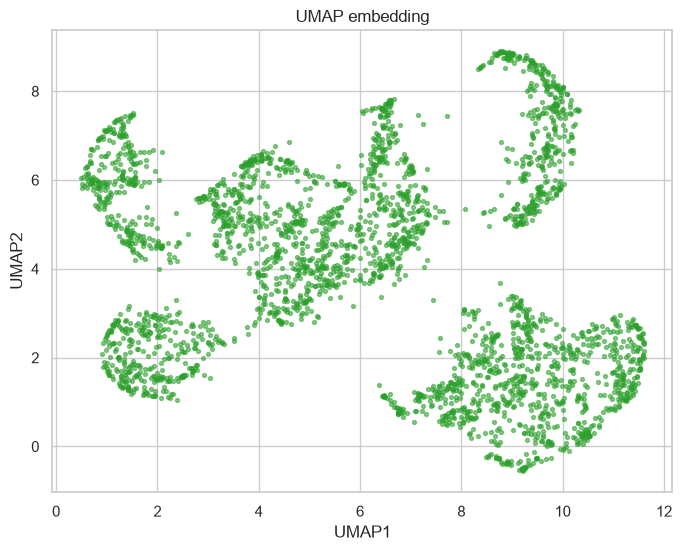

,UMAP1,UMAP2
sample_id,,
69,1.823349,2.818605
92,7.737969,1.369389
131,9.747733,2.876427
187,3.288564,5.278929
188,6.498666,4.068556


In [12]:
umap_positions = make_sample_positions(score.shape[0], UMAP_SAMPLE_SIZE, random_state=RANDOM_STATE + 1)
umap_input = score.iloc[umap_positions, :UMAP_PCA_COMPONENTS]

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.10,
    n_components=2,
    metric='euclidean',
    random_state=RANDOM_STATE,
    n_jobs=1,
)
umap_embedding_array = umap_model.fit_transform(umap_input)

umap_embedding = pd.DataFrame(
    umap_embedding_array,
    index=umap_input.index,
    columns=['UMAP1', 'UMAP2'],
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(umap_embedding['UMAP1'], umap_embedding['UMAP2'], s=8, alpha=0.55, color='tab:green')
ax.set_title('UMAP embedding')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.show()

display(umap_embedding.head())

## 階層的クラスタリングとデンドログラム

このセルでは、サンプル抽出したデータに対して、ユークリッド距離・ウォード法で階層的クラスタリングを行う。

デンドログラムは全葉を表示すると読みにくいため、最後の `DENDROGRAM_LAST_P` 個の結合が見えるように省略表示する。

階層的クラスタリングのクラスタ別サンプル数:


,n_samples
hierarchical_cluster,
1,99
2,353
3,133
4,362
5,92
6,7
7,151
8,1
9,1


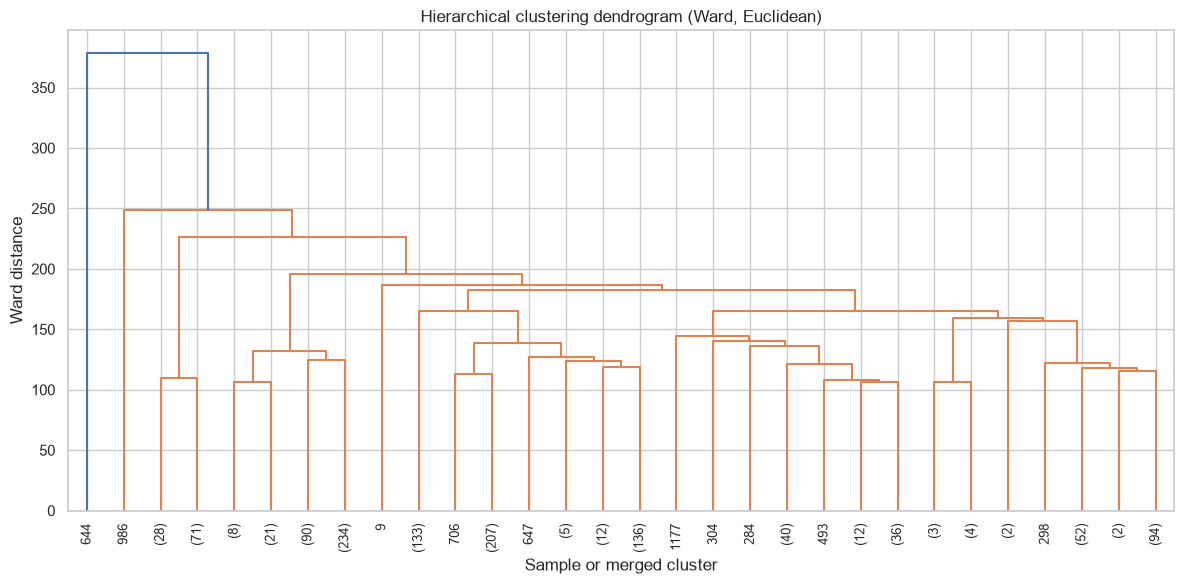

In [13]:
hierarchical_positions = make_sample_positions(
    auto_x_df.shape[0],
    HIERARCHICAL_SAMPLE_SIZE,
    random_state=RANDOM_STATE + 2,
)
hierarchical_input = auto_x_df.iloc[hierarchical_positions]
hierarchical_score = score.iloc[hierarchical_positions]

# linkage() で階層的クラスタリングを実行する。
# metric='euclidean' がユークリッド距離、method='ward' がウォード法を表す。
hierarchical_linkage = linkage(hierarchical_input, metric='euclidean', method='ward')

# fcluster() で、指定したクラスタ数になるようにデンドログラムを切る。
hierarchical_clusters = fcluster(hierarchical_linkage, t=N_CLUSTERS, criterion='maxclust')

hierarchical_result = pd.DataFrame(
    {
        'hierarchical_cluster': hierarchical_clusters,
        'PC1': hierarchical_score['PC1'],
        'PC2': hierarchical_score['PC2'],
    },
    index=hierarchical_input.index,
)

hierarchical_cluster_counts = hierarchical_result['hierarchical_cluster'].value_counts().sort_index()
print('階層的クラスタリングのクラスタ別サンプル数:')
display(hierarchical_cluster_counts.to_frame('n_samples'))

plt.figure(figsize=(12, 6))
dendrogram(
    hierarchical_linkage,
    truncate_mode='lastp',
    p=DENDROGRAM_LAST_P,
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=9,
)
plt.title('Hierarchical clustering dendrogram (Ward, Euclidean)')
plt.xlabel('Sample or merged cluster')
plt.ylabel('Ward distance')
plt.tight_layout()
plt.show()

## k-meansによる非階層的クラスタリング

このセルでは、全データの標準化済み特徴量に対して k-means を行う。

クラスタリングは `auto_x_df` に対して実行し、そのクラスタ番号を後でPCAのPC1・PC2平面に重ねて表示する。

In [14]:
kmeans_input = auto_x_df

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
)
kmeans_clusters = kmeans.fit_predict(kmeans_input) + 1

score_with_clusters = score.copy()
score_with_clusters['kmeans_cluster'] = kmeans_clusters

kmeans_cluster_counts = score_with_clusters['kmeans_cluster'].value_counts().sort_index()
print('k-meansのクラスタ別サンプル数:')
display(kmeans_cluster_counts.to_frame('n_samples'))

k-meansのクラスタ別サンプル数:


,n_samples
kmeans_cluster,
1,5857
2,9004
3,6019
4,3816
5,8997
6,6721
7,3134
8,1939
9,11000


## クラスタリング結果をPCAの図に併記

このセルでは、階層的クラスタリングと k-means のクラスタ番号を、PC1・PC2の散布図に色として重ねる。

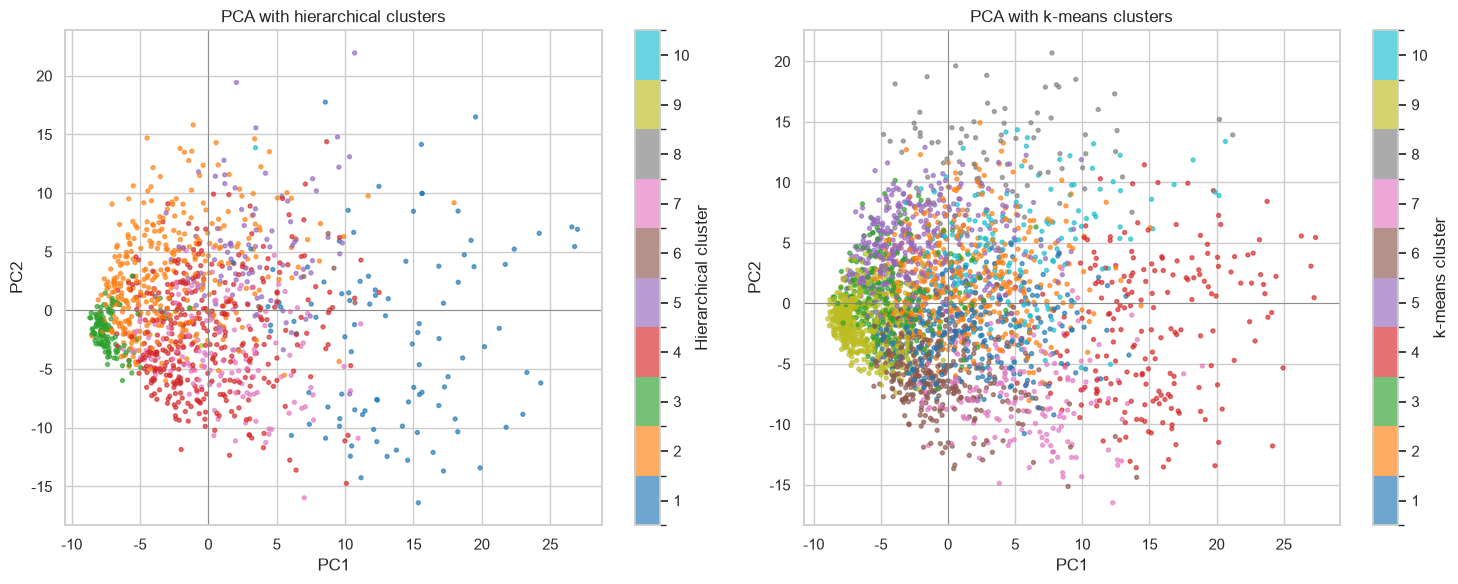

In [15]:
cluster_cmap, cluster_norm = make_cluster_color_settings(N_CLUSTERS)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 階層的クラスタリングはサンプル抽出した点に対する結果を表示する。
plot_pca_scatter(
    axes[0],
    hierarchical_result,
    title='PCA with hierarchical clusters',
    color_values=hierarchical_result['hierarchical_cluster'],
    cmap=cluster_cmap,
    norm=cluster_norm,
    colorbar_label='Hierarchical cluster',
)

# k-means は全データで計算し、表示は見やすいようにサンプル抽出した点だけにする。
kmeans_plot_df = score_with_clusters.iloc[plot_positions].copy()
plot_pca_scatter(
    axes[1],
    kmeans_plot_df,
    title='PCA with k-means clusters',
    color_values=kmeans_plot_df['kmeans_cluster'],
    cmap=cluster_cmap,
    norm=cluster_norm,
    colorbar_label='k-means cluster',
)

plt.tight_layout()
plt.show()

## UMAPにk-meansクラスタを重ねて確認

課題ではクラスタリング結果をPCAの図に併記すればよいが、UMAP上でも同じクラスタ番号を色で確認しておく。

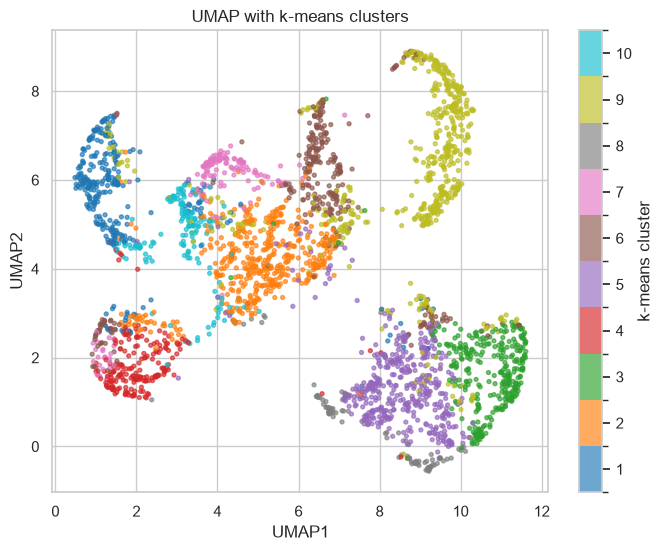

In [16]:
umap_with_clusters = umap_embedding.copy()
umap_with_clusters['kmeans_cluster'] = score_with_clusters.iloc[umap_positions]['kmeans_cluster'].to_numpy()

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    umap_with_clusters['UMAP1'],
    umap_with_clusters['UMAP2'],
    c=umap_with_clusters['kmeans_cluster'],
    s=8,
    alpha=0.65,
    cmap=cluster_cmap,
    norm=cluster_norm,
)
colorbar = plt.colorbar(scatter, ax=ax, ticks=np.arange(1, N_CLUSTERS + 1))
colorbar.set_label('k-means cluster')
ax.set_title('UMAP with k-means clusters')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.show()

## 結果の表を確認

このセルでは、各サンプルのPCAスコアと k-means クラスタ番号、UMAP座標、階層的クラスタリング結果の一部を表で確認する。

In [17]:
print('PCA score + k-means cluster')
display(score_with_clusters[['PC1', 'PC2', 'kmeans_cluster']].head(10))

print('UMAP embedding + k-means cluster')
display(umap_with_clusters.head(10))

print('Hierarchical clustering result')
display(hierarchical_result.head(10))

PCA score + k-means cluster


,PC1,PC2,kmeans_cluster
sample_id,,,
0,-0.922137,-4.814713,6
1,8.709007,-7.754373,4
2,2.328405,9.431358,8
3,-6.582162,-3.746233,9
4,-5.183238,3.133286,5
5,2.198402,-3.068389,7
6,-6.773347,0.823085,9
7,1.926902,-5.406270,7
8,-7.822336,0.191822,9


UMAP embedding + k-means cluster


,UMAP1,UMAP2,kmeans_cluster
sample_id,,,
69,1.823349,2.818605,2
92,7.737969,1.369389,5
131,9.747733,2.876427,6
187,3.288564,5.278929,10
188,6.498666,4.068556,2
198,4.334521,3.664698,2
223,11.260102,1.203815,3
237,8.384393,1.895784,5
244,5.464909,3.931167,2


Hierarchical clustering result


,hierarchical_cluster,PC1,PC2
sample_id,,,
77,3,-7.270895,-3.225719
83,7,1.824042,-4.247275
253,7,10.949732,-10.886312
285,2,-6.659304,0.831904
325,7,7.088901,-8.203991
342,2,-5.838018,0.237554
427,1,18.239285,-10.339152
450,3,-7.362710,-2.616119
576,2,-4.510319,6.891480


## 教師あり学習と教師なし学習の違い

教師あり学習は、説明変数 `x` と正解ラベル・目的変数 `y` の対応を使って、未知データの `y` を予測する方法である。第3回〜第5回で扱った回帰や分類は教師あり学習に含まれる。

教師なし学習は、正解ラベル `y` を使わず、説明変数 `x` の構造を調べる方法である。今回の PCA、UMAP、階層的クラスタリング、k-means は教師なし学習であり、データのばらつき、近さ、まとまりを可視化・分析するために使う。